# Testing the Performance of Row- and Column-wise Memory Layouts

## Import Libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time

## Functions to Test

In [2]:
size = 10000
numpy_square = np.random.rand(size, size)
fortran_square = np.asfortranarray(numpy_square)

squares = [
    ("numpy_square", numpy_square),
    ("fortran_square", fortran_square)
]

def compute_row_sums(size, square):
    total_sum = 0
    for i in range(size):
        row_sum = np.sum(square[i, :])
        total_sum += row_sum
    return total_sum

def compute_col_sums(size, square):
    total_sum = 0
    for j in range(size):
        col_sum = np.sum(square[:, j])
        total_sum += col_sum
    return total_sum

test_functions = [compute_row_sums, compute_col_sums]

## Testing the Memory Layout Performance

Type of Square: numpy_square
Used Function: compute_row_sums
Compute Time: 0.1153

Used Function: compute_col_sums
Compute Time: 0.9012

Type of Square: fortran_square
Used Function: compute_row_sums
Compute Time: 0.8772

Used Function: compute_col_sums
Compute Time: 0.0916

C-order col/row ratio:, 7.8189
F-order row/col ratio:, 9.5740


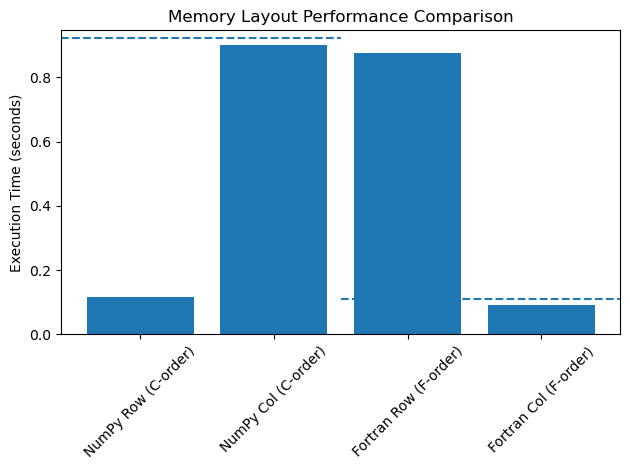

In [18]:
def test_layout_performance(squares, size, test_functions):
    test_times = []

    for square_type, square in squares:
        print(f'Type of Square: {square_type}')

        for test_function in test_functions:
            print(f'Used Function: {test_function.__name__}')

            start_time = time.perf_counter()
            total_sum = test_function(size, square)
            test_time = time.perf_counter() - start_time
            test_times.append(test_time)
            print(f'Compute Time: {test_time:.4f}\n')

    return test_times

test_times = test_layout_performance(squares, size, test_functions)

print(f"C-order col/row ratio:, {(test_times[1] / test_times[0]):.4f}")
print(f"F-order row/col ratio:, {(test_times[2] / test_times[3]):.4f}")

labels = [
    "NumPy Row (C-order)",
    "NumPy Col (C-order)",
    "Fortran Row (F-order)",
    "Fortran Col (F-order)"
]

plt.figure()
plt.bar(labels, test_times)
plt.xticks(rotation=45)
plt.ylabel("Execution Time (seconds)")
plt.title("Memory Layout Performance Comparison")

# we expect row computation to be ~4x faster for C-order array
expected_numpy_col = test_times[0] * 8
plt.axhline(expected_numpy_col, xmax=0.5, linestyle='--')

# we expect column computation to be ~4x faster for Fortran-order array
expected_fortran_row = test_times[2] / 8
plt.axhline(expected_fortran_row, xmin=0.5, linestyle='--')

plt.tight_layout()
plt.show()